<a href="https://colab.research.google.com/github/code-with-thara/data-science-internship-project/blob/main/EDA-project/eda-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


In [2]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


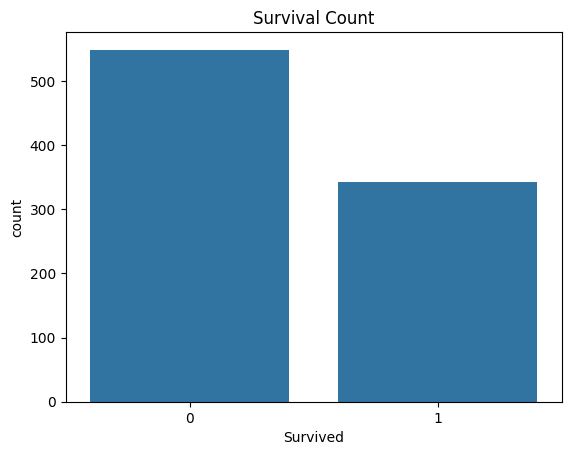

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

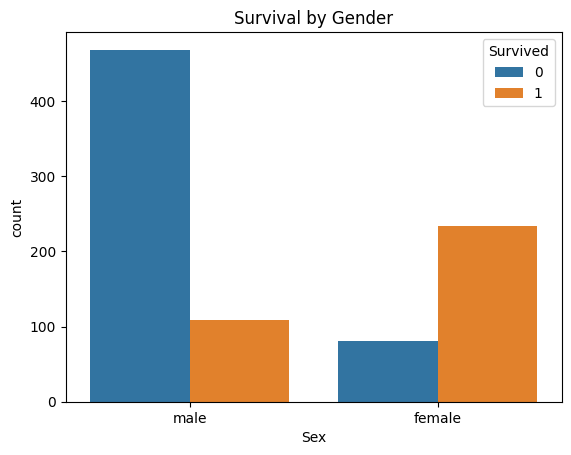

In [8]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

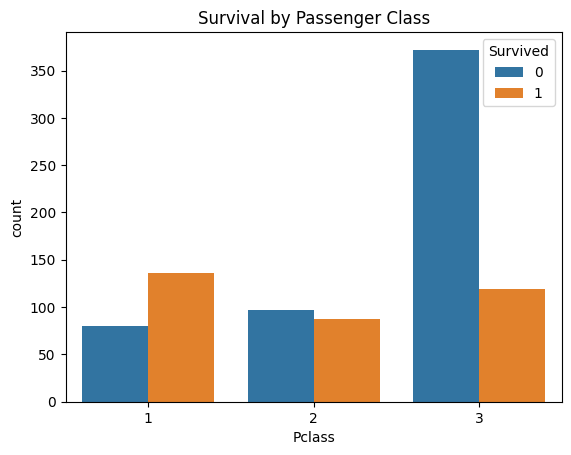

In [9]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

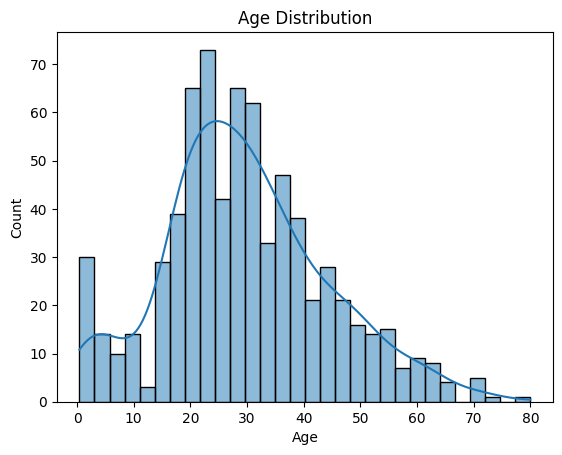

In [10]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

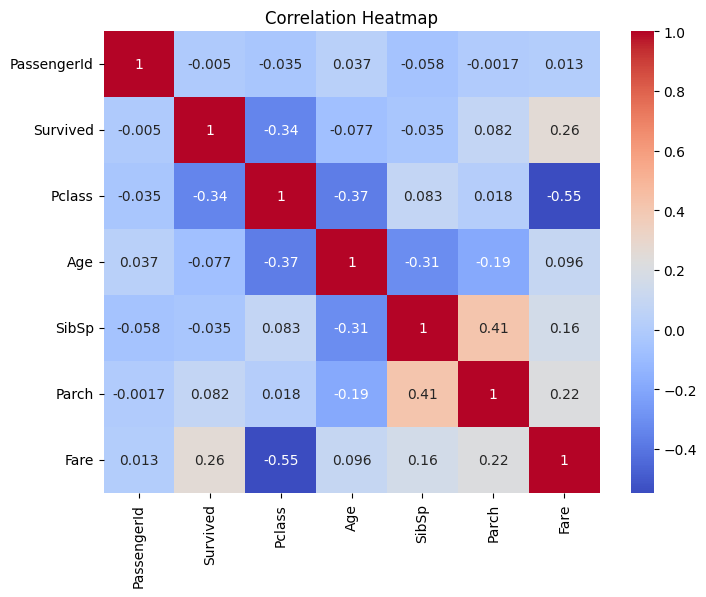

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Handling Missing Values

Based on the `df.isnull().sum()` output, we need to address missing values in 'Age', 'Cabin', and 'Embarked' columns.

In [14]:
# Fill missing 'Embarked' values with the most frequent value
most_frequent_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(most_frequent_embarked, inplace=True)

print(f"Missing 'Embarked' values filled with: {most_frequent_embarked}")

Missing 'Embarked' values filled with: S


/tmp/ipykernel_1980/3785883080.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(most_frequent_embarked, inplace=True)


In [15]:
# Fill missing 'Age' values with the median age
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

print(f"Missing 'Age' values filled with median: {median_age}")

Missing 'Age' values filled with median: 28.0


/tmp/ipykernel_1980/1165394404.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


In [16]:
# Create a new feature 'Has_Cabin' from 'Cabin' column
df['Has_Cabin'] = df['Cabin'].apply(lambda x: 1 if pd.notnull(x) else 0)

# Drop the original 'Cabin' column as it has too many missing values
df.drop('Cabin', axis=1, inplace=True)

print("'Cabin' column replaced with 'Has_Cabin' feature and original 'Cabin' dropped.")

'Cabin' column replaced with 'Has_Cabin' feature and original 'Cabin' dropped.


### Verify Missing Values After Imputation

In [17]:
display(df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [26]:
if 'Sex' in df.columns:
    df = pd.get_dummies(df, columns=['Sex'], drop_first=True, prefix='Sex')

if 'Embarked' in df.columns:
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, prefix='Embarked')

if 'Title' in df.columns:
    df = pd.get_dummies(df, columns=['Title'], drop_first=True, prefix='Title')

print("Categorical columns 'Sex', 'Embarked', and 'Title' have been one-hot encoded (if they existed).")
display(df.head())

Categorical columns 'Sex', 'Embarked', and 'Title' have been one-hot encoded (if they existed).


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Has_Cabin,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,2,0,True,False,True,False,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,2,0,False,False,False,False,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,1,1,False,False,True,True,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,2,0,False,False,True,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,1,1,True,False,True,False,True,False,False,False


### Final Data Check

In [21]:
print("DataFrame information after encoding:")
display(df.info())
print("First 5 rows of the processed DataFrame:")
display(df.head())

DataFrame information after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PassengerId         891 non-null    int64  
 1   Survived            891 non-null    int64  
 2   Pclass              891 non-null    int64  
 3   Name                891 non-null    object 
 4   Age                 891 non-null    float64
 5   SibSp               891 non-null    int64  
 6   Parch               891 non-null    int64  
 7   Ticket              891 non-null    object 
 8   Fare                891 non-null    float64
 9   Has_Cabin           891 non-null    int64  
 10  FamilySize          891 non-null    int64  
 11  IsAlone             891 non-null    int64  
 12  Sex_male            891 non-null    bool   
 13  Embarked_Q          891 non-null    bool   
 14  Embarked_S          891 non-null    bool   
 15  Title_Miss         

None

First 5 rows of the processed DataFrame:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Has_Cabin,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,2,0,True,False,True,False,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,2,0,False,False,False,False,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,1,1,False,False,True,True,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,2,0,False,False,True,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,1,1,True,False,True,False,True,False,False,False


In [24]:
df_processed = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

print("Dropped 'PassengerId', 'Name', and 'Ticket' columns.")
print("Final DataFrame shape:", df_processed.shape)
print("First 5 rows of the final processed DataFrame:")
display(df_processed.head())

Dropped 'PassengerId', 'Name', and 'Ticket' columns.
Final DataFrame shape: (891, 17)
First 5 rows of the final processed DataFrame:


,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,0,3,22.0,1,0,7.2500,0,2,0,True,False,True,False,True,False,False,False
1,1,1,38.0,1,0,71.2833,1,2,0,False,False,False,False,False,True,False,False
2,1,3,26.0,0,0,7.9250,0,1,1,False,False,True,True,False,False,False,False
3,1,1,35.0,1,0,53.1000,1,2,0,False,False,True,False,False,True,False,False
4,0,3,35.0,0,0,8.0500,0,1,1,True,False,True,False,True,False,False,False


In [25]:
df_processed = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

print("Dropped 'PassengerId', 'Name', and 'Ticket' columns.")
print("Final DataFrame shape:", df_processed.shape)
print("First 5 rows of the final processed DataFrame:")
display(df_processed.head())

Dropped 'PassengerId', 'Name', and 'Ticket' columns.
Final DataFrame shape: (891, 17)
First 5 rows of the final processed DataFrame:


,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess
0,0,3,22.0,1,0,7.2500,0,2,0,True,False,True,False,True,False,False,False
1,1,1,38.0,1,0,71.2833,1,2,0,False,False,False,False,False,True,False,False
2,1,3,26.0,0,0,7.9250,0,1,1,False,False,True,True,False,False,False,False
3,1,1,35.0,1,0,53.1000,1,2,0,False,False,True,False,False,True,False,False
4,0,3,35.0,0,0,8.0500,0,1,1,True,False,True,False,True,False,False,False


Unique titles after grouping:


,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,22
the Countess,1


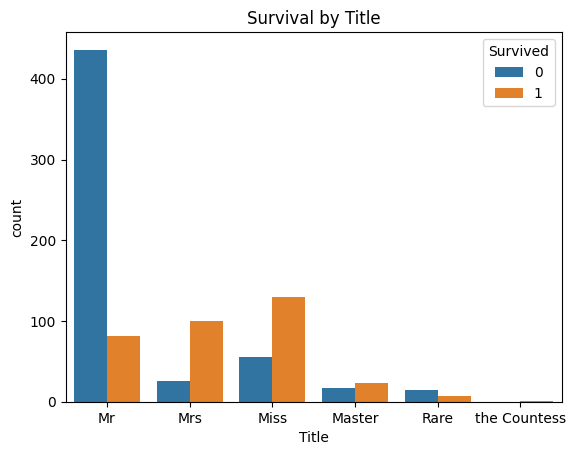

In [18]:
df['Title'] = df['Name'].apply(lambda name: name.split(',')[1].split('.')[0].strip())

# Group less common titles
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("Unique titles after grouping:")
display(df['Title'].value_counts())

sns.countplot(x='Title', hue='Survived', data=df)
plt.title('Survival by Title')
plt.show()

### Creating FamilySize and IsAlone Features

Distribution of FamilySize:


,count
FamilySize,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


Survival by FamilySize:


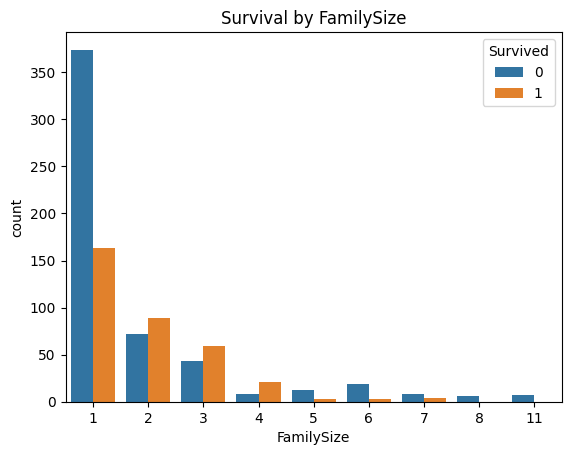

Survival by IsAlone:


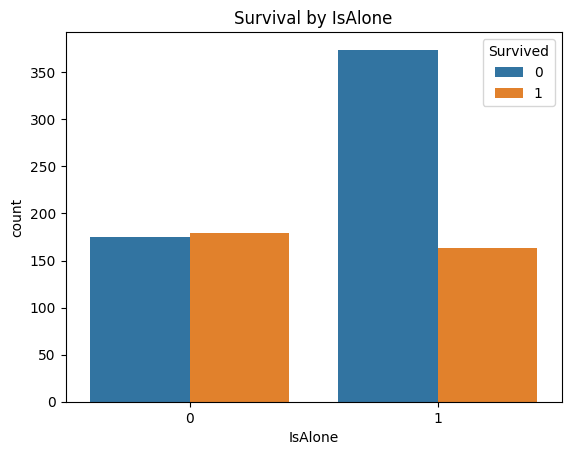

In [19]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = df['FamilySize'].apply(lambda x: 1 if x == 1 else 0)

print("Distribution of FamilySize:")
display(df['FamilySize'].value_counts())

print("Survival by FamilySize:")
sns.countplot(x='FamilySize', hue='Survived', data=df)
plt.title('Survival by FamilySize')
plt.show()

print("Survival by IsAlone:")
sns.countplot(x='IsAlone', hue='Survived', data=df)
plt.title('Survival by IsAlone')
plt.show()